# PottsMPNN energy prediction

`run_energy_prediction` runs PottsMPNN's energy model over a structure and returns an
`EnergyPredictionResult`. With no mutant list it performs a **deep mutational scan** (every
position × every non-wild-type amino acid in each chain), which is exactly the data behind a
per-position mutation-energy heatmap.

The result object holds the per-mutation scores as a DataFrame (`.scores`) and can draw the
heatmap on demand with `.plot_heatmap()`.

> PottsMPNN is bundled as the `external/PottsMPNN` submodule; no path configuration is needed.

In [2]:
from pathlib import Path

# import torch


In [3]:
import snekwrap.config as config
from snekwrap.wrappers.pottsmpnn import run_energy_prediction

2026-06-19 09:59:58.894 | INFO     | snekwrap:<module>:2 - Importing snekwrap package
2026-06-19 09:59:58.895 | INFO     | snekwrap:<module>:3 - importing config
2026-06-19 09:59:59.914 | INFO     | snekwrap:<module>:5 - importing external wrappers
2026-06-19 10:00:00.113 | INFO     | snekwrap.wrappers:<module>:3 - importing colabfold
2026-06-19 10:00:00.115 | INFO     | snekwrap.wrappers:<module>:5 - importing esmfold
2026-06-19 10:00:06.616 | INFO     | snekwrap.wrappers:<module>:7 - importing MSAs
2026-06-19 10:00:06.617 | INFO     | snekwrap.wrappers:<module>:9 - importing protein_mpnn
2026-06-19 10:00:06.620 | INFO     | snekwrap.wrappers:<module>:11 - importing RFDiffusion
2026-06-19 10:00:06.702 | INFO     | snekwrap:<module>:7 - importing database_queries
2026-06-19 10:00:06.852 | INFO     | snekwrap:<module>:9 - importing sequence_utils


In [4]:


# Example PDBs ship with the PottsMPNN submodule.
example_pdbs = Path(config.POTTSMPNN_REPO) / "inputs" / "example_pdbs"
pdb = example_pdbs / "3dkm.pdb"  # small single-chain example, fast on CPU

# dev = "cuda" if torch.cuda.is_available() else "cpu"
dev = "cpu"
print(f"running on: {dev}")

running on: cpu


## Deep mutational scan

One call: pass the PDB (and any config as keyword arguments). The default model is
`vanilla_model_weights/pottsmpnn_msa_20.pt`; `ddG=True` returns energies relative to the
wild type (wild type centered at 0).

In [5]:
result = run_energy_prediction(pdb, dev=dev)

print("pdb:", result.pdb_name)
print("chains:", result.chain_order)
print("scored mutants:", len(result.scores))
result.scores.head()

100%|██████████| 1/1 [00:00<00:00,  2.92it/s]


pdb: 3dkm
chains: ['A']
scored mutants: 1368


,pdb,mutant,wildtype,ddG_pred,ddG_expt
0,3dkm,ALYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,0.999756,NaN
1,3dkm,CLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,2.419434,NaN
2,3dkm,DLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,-0.686035,NaN
3,3dkm,ELYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,0.079102,NaN
4,3dkm,FLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,2.476562,NaN


## Heatmap

`plot_heatmap()` draws the [20 amino acids × positions] heatmap and **returns the matplotlib
`Figure`**, so you can customize it (titles, annotations, size) and re-save. Returning it as the
last line of a cell displays it; assign it (`fig = result.plot_heatmap()`) to modify it first.
Pass `save_path` to also write a PNG.

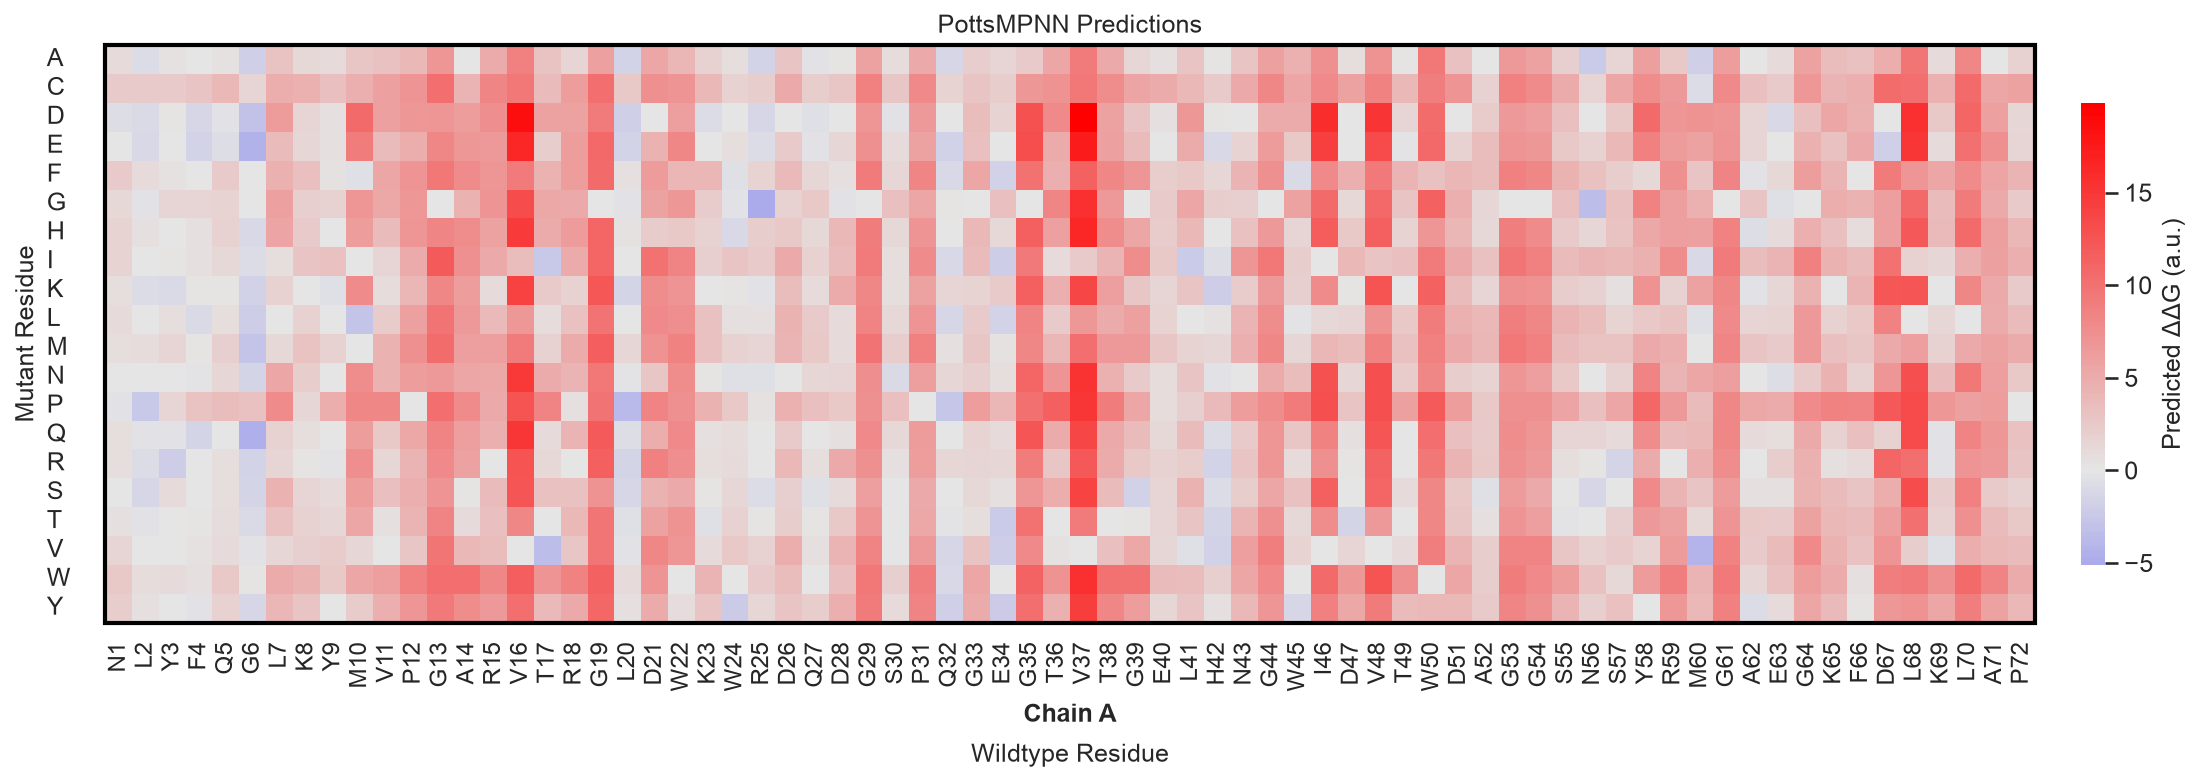

In [6]:
result.plot_heatmap()

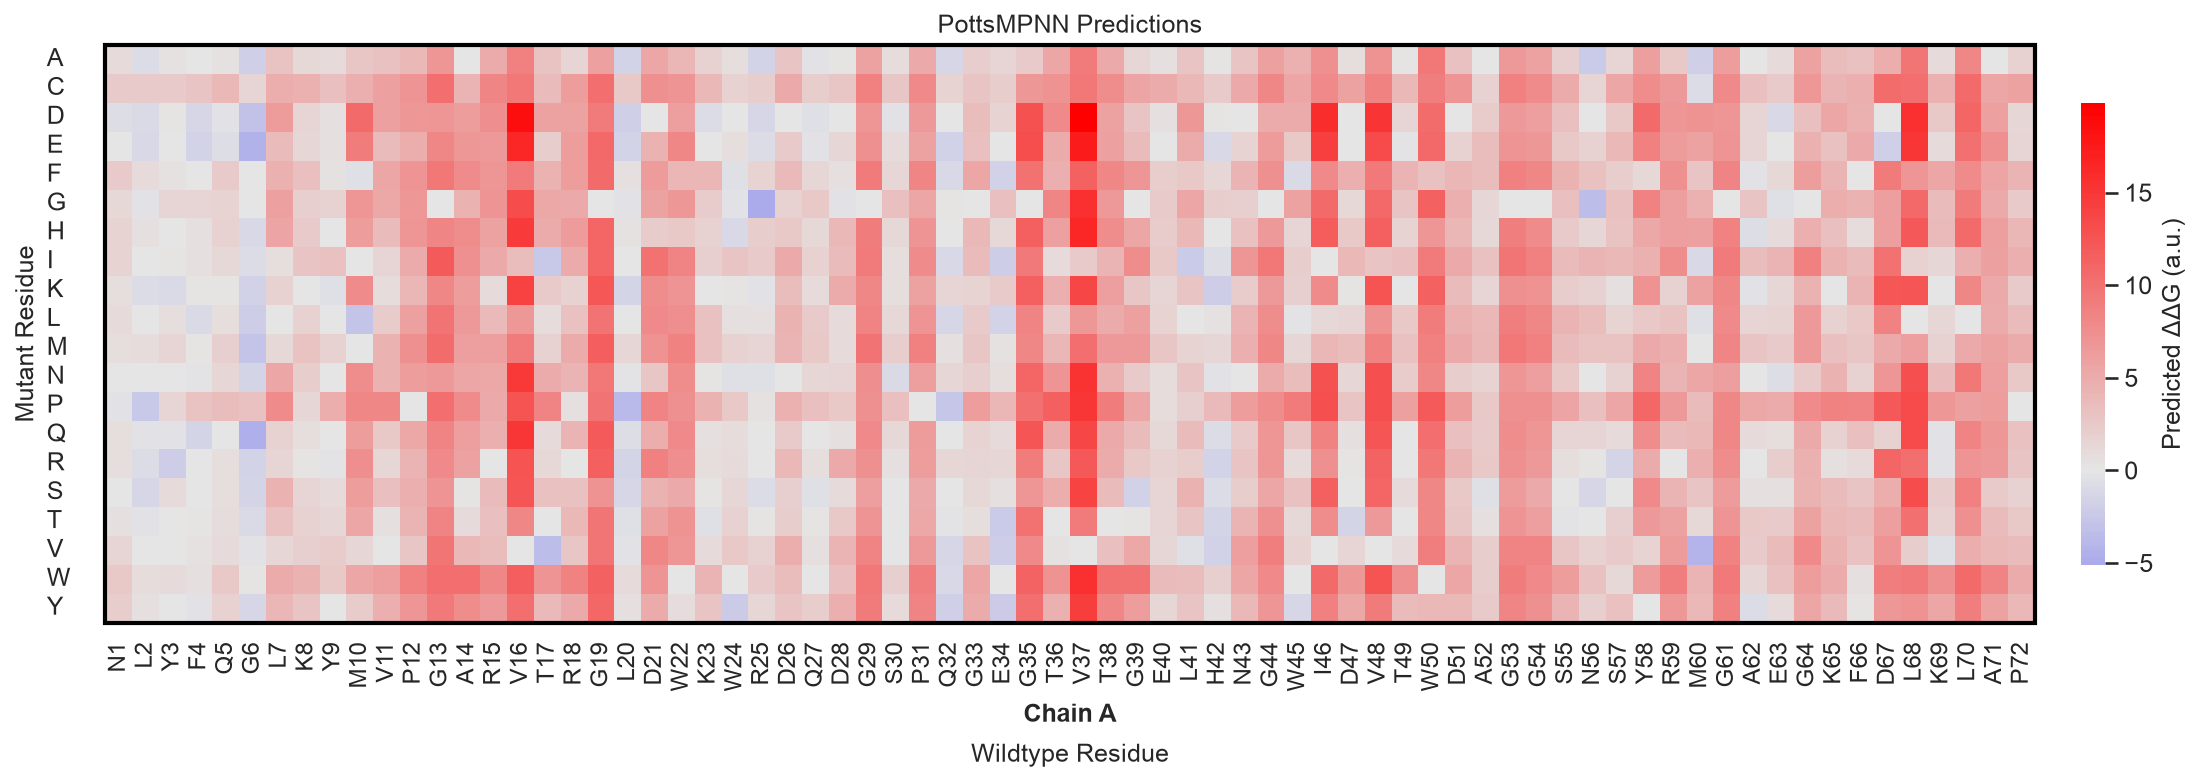

In [7]:
result.plot_heatmap(save_path="3dkm_ddg_heatmap.png")

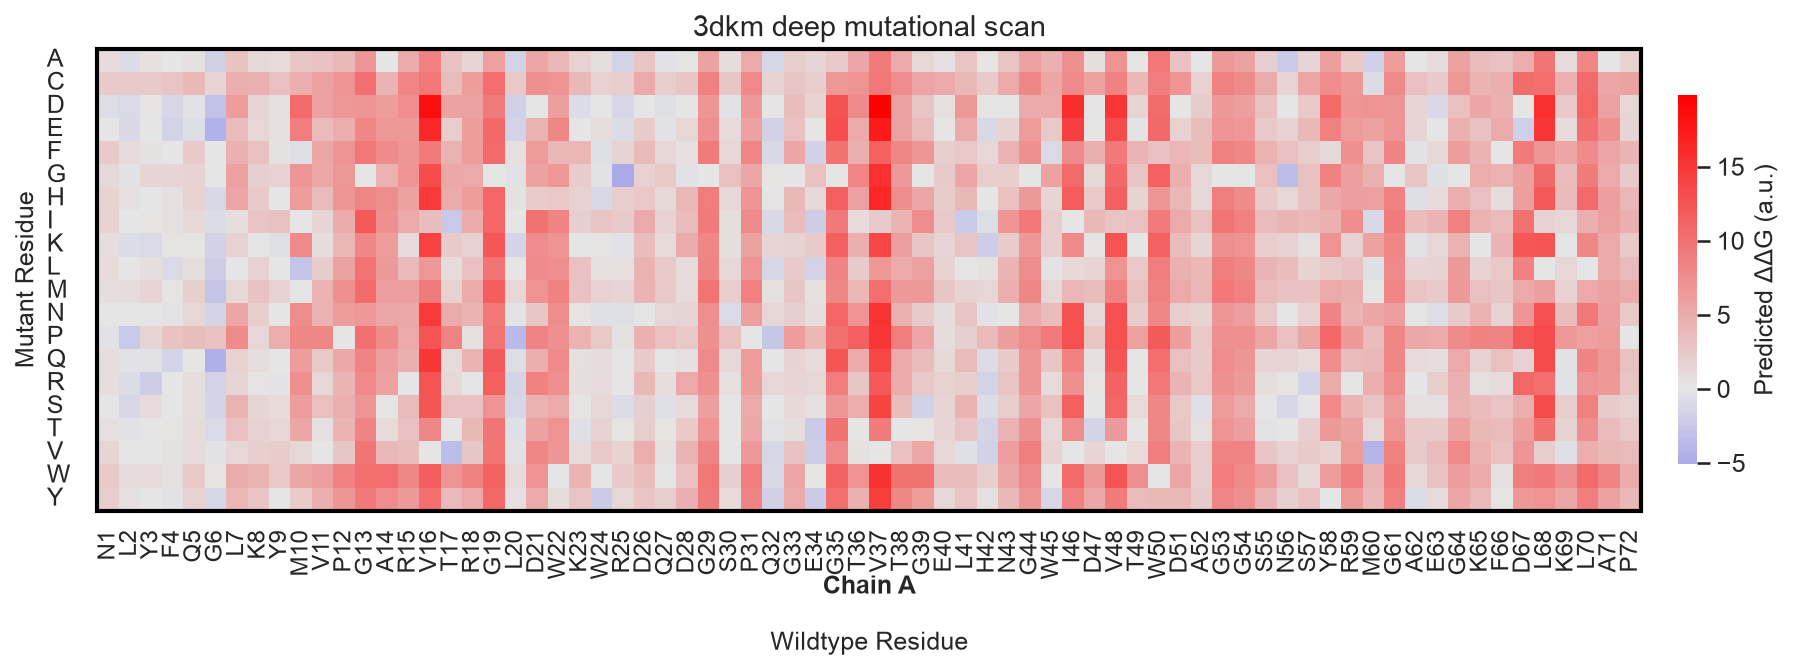

In [8]:
# plot_heatmap returns the Figure, so you can tweak it however you like
fig = result.plot_heatmap()
ax = fig.axes[0]  # the heatmap axes (fig.axes[1] is the colorbar)
ax.set_title("3dkm deep mutational scan", fontsize=14)
fig.set_size_inches(16, 4)
fig  # redisplay the modified figure

## Multi-chain complexes

For a complex you can restrict the scan to particular chains with `exclude_chains`, and zoom
the heatmap to a position range per chain with `chain_ranges` (inclusive, 1-indexed).

`6w25` is a peptide (chain A) bound to a protein (chain B); here we scan only chain B.

100%|██████████| 1/1 [00:05<00:00,  5.10s/it]


chains: ['A', 'B'] | scored mutants: 8892


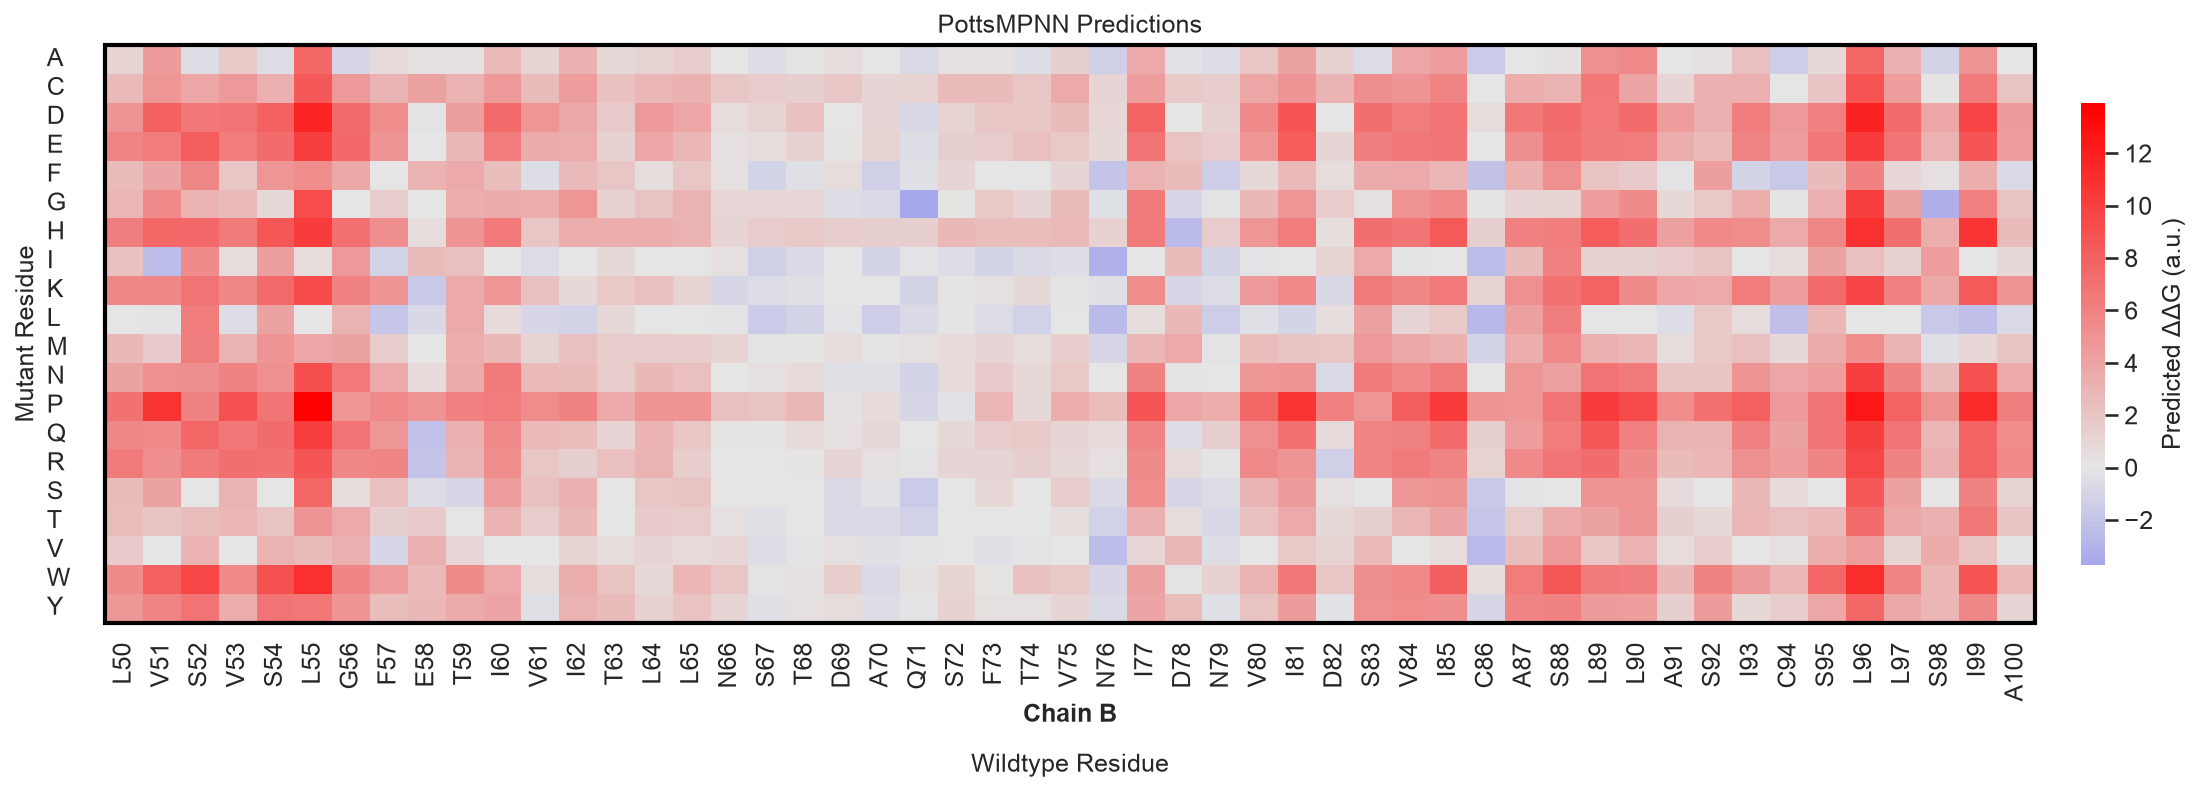

In [9]:
complex_result = run_energy_prediction(
    example_pdbs / "6w25.pdb",
    exclude_chains=["A"],  # scan chain B only
    dev=dev,
)

print("chains:", complex_result.chain_order, "| scored mutants:", len(complex_result.scores))

# zoom the heatmap to chain B positions 50-100
complex_result.plot_heatmap(chain_ranges={"B": [50, 100]})

## Binding energy

To predict how mutations affect **binding** instead of stability, pass `binding_energy_json` —
a mapping from the PDB name to the chain partitions of the complex (its binding partners). The
predicted value then becomes the change in binding energy, E(bound) − Σ E(unbound partitions),
so positive values indicate mutations that weaken binding.

Here we scan the `6w25` peptide (chain A) and split the complex into the peptide `[A]` and its
receptor `[B]`. Since only chain A is scanned, we pass `only_mutated_positions=True` to
`plot_heatmap` so the heatmap shows just the scanned positions instead of every position in the
(much larger) receptor chain.

100%|██████████| 1/1 [00:00<00:00,  1.26it/s]


binding ΔΔG predictions: 114


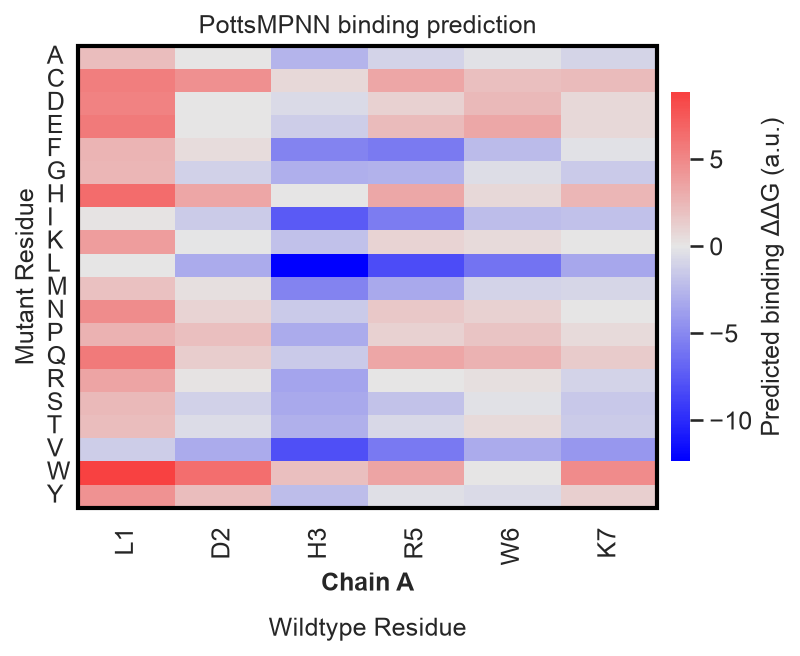

In [16]:
binding_result = run_energy_prediction(
    example_pdbs / "6w25.pdb",
    exclude_chains=["B"],                          # scan the peptide (chain A)
    binding_energy_json={"6w25": [["A"], ["B"]]},  # complex partitions: peptide [A] vs receptor [B]
    mean_norm=True,
    dev=dev,
)
print("binding ΔΔG predictions:", len(binding_result.scores))

# Only the peptide (chain A) was scanned, so use only_mutated_positions=True to drop the
# hundreds of un-scanned chain-B columns (otherwise the heatmap is mostly empty).
fig = binding_result.plot_heatmap(
    only_mutated_positions=True,
    title="PottsMPNN binding prediction",
    clabel=r"Predicted binding $\Delta\Delta$G (a.u.)",
)
fig.set_size_inches(6, 4)
fig